# Введение в машинное обучение


In [1]:
import re
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
from IPython.display import display, Markdown

## Теорема Байеса
Теорема Байеса — это фундаментальный результат теории вероятностей, который позволяет обновлять наши представления о вероятности события на основе новой информации. Она лежит в основе многих алгоритмов машинного обучения и является ключевым инструментом для принятия решений в условиях неопределенности.

<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/bayes.png" alt="Описание изображения" />
</center>

### Задание 1. Условная вероятность
Прежде чем перейти к теореме Байеса, необходимо разобраться с понятием условной
вероятности. Условная вероятность P(A|B) показывает вероятность наступления события A при условии, что событие B уже произошло.

1. Напиши формулу условной вероятности в нотации LaTeX.
2. Реши следующую задачу: В коробке лежат 5 красных и 3 синих шара. Из коробки наугад вынимают два шара последовательно, без возврата. Какова вероятность того, что второй шар будет красным, если первый шар был синим? Вычисли ответ программно и выведи результат.
3. Реши следующую задачу: монету подбрасывают дважды. Событие A — первый бросок дал орла, событие B — второй бросок дал орла. Являются ли события A и B независимыми? Проверь это программно, вычислив P(A), P(B), P(A|B) и P(A и B). Сделай вывод о независимости событий.

In [3]:
display(Markdown(r"$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}$$"))

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}$$

In [4]:
red_balls = 5
blue_balls_after = 2
p_second_red_given_first_blue = red_balls / (red_balls + blue_balls_after)
print(f"P(второй красный | первый синий) = {p_second_red_given_first_blue:.6f}")

P(второй красный | первый синий) = 0.714286


In [5]:
p_a = 0.5
p_b = 0.5
p_a_and_b = 0.25
p_a_given_b = p_a_and_b / p_b

print(f"P(A) = {p_a}")
print(f"P(B) = {p_b}")
print(f"P(A ∩ B) = {p_a_and_b}")
print(f"P(A|B) = {p_a_given_b}")
print("Вывод: события A и B независимы, так как P(A|B) = P(A).")

P(A) = 0.5
P(B) = 0.5
P(A ∩ B) = 0.25
P(A|B) = 0.5
Вывод: события A и B независимы, так как P(A|B) = P(A).


### Задание 2. Тест на коронавирус

Теорема Байеса находит широкое применение в медицине, особенно при интерпретации результатов диагностических тестов.
<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/error_type.png" alt="Типы ошибок" />
</center>

1. Напиши формулу теоремы Байеса в нотации LaTeX. Объясни, что означает каждый из компонентов формулы.
2. Дана задача: на планете живет 8 миллиардов человек. Известно, что заболел 1% населения. Тест на коронавирус имеет точность 95% (то есть 5% приходится на ошибки первого и второго рода: ложноположительные и ложноотрицательные результаты). Предположим, что вероятность ложноположительного результата (ошибка первого рода) составляет 5%, а вероятность ложноотрицательного результата (ошибка второго рода) составляет 5%. Ты сдал тест, и он оказался положительным. Какова вероятность того, что ты действительно болен? Реши задачу, используя теорему Байеса. Выведи результат с пояснениями.


In [6]:
display(Markdown(r"$$P(A\mid B)=\frac{P(B\mid A)\cdot P(A)}{P(B)}$$"))
display(Markdown(r"""
Где:
- $P(A\mid B)$ — апостериорная вероятность.
- $P(B\mid A)$ — правдоподобие.
- $P(A)$ — априорная вероятность.
- $P(B)$ — вероятность наблюдения $B$.
"""))

$$P(A\mid B)=\frac{P(B\mid A)\cdot P(A)}{P(B)}$$


Где:
- $P(A\mid B)$ — апостериорная вероятность.
- $P(B\mid A)$ — правдоподобие.
- $P(A)$ — априорная вероятность.
- $P(B)$ — вероятность наблюдения $B$.


In [7]:
p_disease = 0.01
p_no_disease = 1 - p_disease

# Ошибки 1 и 2 рода по 5%
false_positive = 0.05          # P(тест+ | не болен)
false_negative = 0.05          # P(тест- | болен)

p_pos_given_disease = 1 - false_negative
p_pos_given_no_disease = false_positive

p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * p_no_disease
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f"P(болен | тест +) = {p_disease_given_pos:.6f} ({p_disease_given_pos*100:.2f}%)")
print("Комментарий: при низкой доле больных даже небольшой уровень ложноположительных сильно влияет на результат.")

P(болен | тест +) = 0.161017 (16.10%)
Комментарий: при низкой доле больных даже небольшой уровень ложноположительных сильно влияет на результат.


### Задание 3. Улучшаем тест

Результат предыдущей задачи показывает, что даже при высокой точности теста вероятность того, что человек действительно болен при положительном результате, может быть довольно низкой. Это связано с тем, что доля больных в популяции невелика (1%).

Врачи готовы улучшить тест, но могут исправить либо ошибку первого рода (ложноположительные результаты), либо ошибку второго рода (ложноотрицательные результаты). Необходимо выбрать, какую ошибку уменьшать.

<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/dilemma.png" alt="Дилемма" />
</center>

1. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки первого рода (ложноположительные результаты) при фиксированной ошибке второго рода (5%). Ошибка первого рода должна изменяться от 0% до 5% с шагом 0.5%.
2. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки второго рода (ложноотрицательные результаты) при фиксированной ошибке первого рода (5%). Ошибка второго рода должна изменяться от 0% до 5% с шагом 0.5%.
3. Проанализируй оба графика и сделай вывод: какую ошибку следует уменьшать и почему? Объясни свой выбор, учитывая практические последствия ложноположительных и ложноотрицательных результатов в медицинской диагностике.

In [8]:
def p_disease_given_positive(false_positive, false_negative, p_disease=0.01):
    """P(болен | тест+) по теореме Байеса."""
    p_no_disease = 1 - p_disease
    p_pos_given_disease = 1 - false_negative
    p_pos_given_no_disease = false_positive
    p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * p_no_disease
    return (p_pos_given_disease * p_disease) / p_pos

In [9]:
err_range = np.arange(0.0, 0.0501, 0.005)

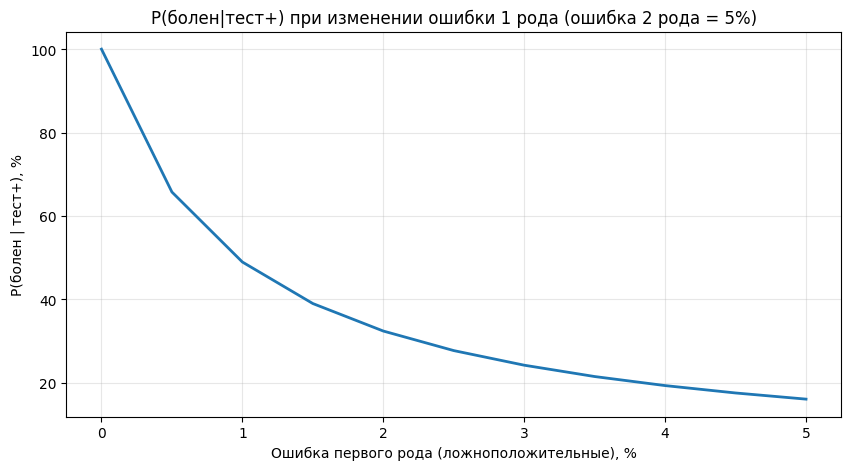

In [10]:
fn_fixed = 0.05
p1 = [p_disease_given_positive(fp, fn_fixed) for fp in err_range]

plt.figure(figsize=(10, 5))
plt.plot(err_range * 100, np.array(p1) * 100, linewidth=2)
plt.xlabel("Ошибка первого рода (ложноположительные), %")
plt.ylabel("P(болен | тест+), %")
plt.title("P(болен|тест+) при изменении ошибки 1 рода (ошибка 2 рода = 5%)")
plt.grid(True, alpha=0.3)
plt.show()

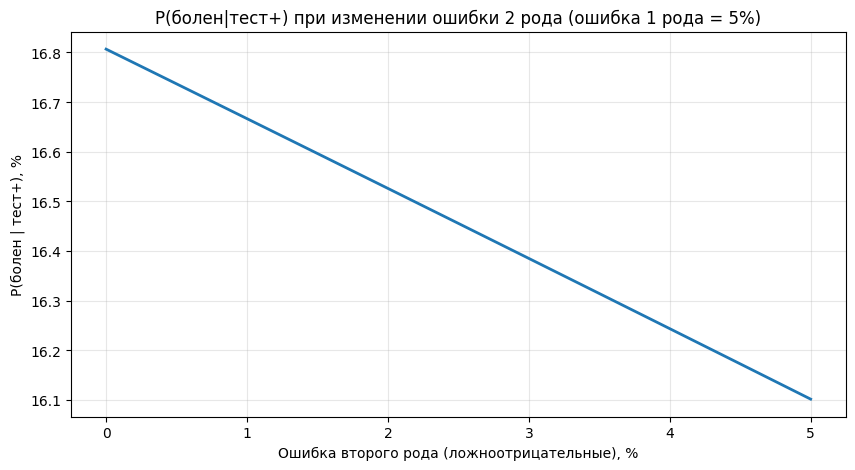

In [11]:
fp_fixed = 0.05
p2 = [p_disease_given_positive(fp_fixed, fn) for fn in err_range]

plt.figure(figsize=(10, 5))
plt.plot(err_range * 100, np.array(p2) * 100, linewidth=2)
plt.xlabel("Ошибка второго рода (ложноотрицательные), %")
plt.ylabel("P(болен | тест+), %")
plt.title("P(болен|тест+) при изменении ошибки 2 рода (ошибка 1 рода = 5%)")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
print("Вывод:")
print("- При малой распространенности болезни ложноположительные (ошибка 1 рода) сильно 'размывают' результат теста.")
print("- Поэтому уменьшение ошибки 1 рода обычно сильнее повышает P(болен|тест+), чем уменьшение ошибки 2 рода.")

Вывод:
- При малой распространенности болезни ложноположительные (ошибка 1 рода) сильно 'размывают' результат теста.
- Поэтому уменьшение ошибки 1 рода обычно сильнее повышает P(болен|тест+), чем уменьшение ошибки 2 рода.


## Наивный байесовский классификатор

Наивный байесовский классификатор — это простой, но эффективный алгоритм классификации, основанный на
теореме Байеса. Его идея в том, чтобы сравнивать апостериорные вероятности классов и выбирать класс с
наибольшей вероятностью.

Алгоритм называют "наивным", потому что он делает упрощающее предположение об условной независимости
признаков при фиксированном классе. На практике это предположение часто нарушается, но модель всё равно
работает хорошо: она быстро обучается, устойчива к высокоразмерным разреженным признакам и даёт
интерпретируемые вероятности.

В этом разделе ты обучишь наивный байесовский классификатор для определения спам‑сообщений в
электронной почте.

<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/nbc.png" alt="NBC" />
</center>

### Задание 4. Загрузка данных

1. Загрузи данные из файла `datasets/emails.csv` с помощью библиотеки `pandas`. Файл содержит два столбца: `text` (текст письма) и `spam` (метка: 1 — спам, 0 — не спам).
2. Выведи размерность DataFrame (количество строк и столбцов).
3. Построй круговую диаграмму (pie chart) с помощью библиотеки `matplotlib`, отображающую распределение писем по классам (спам / не спам). Добавь легенду и информативный заголовок.

In [13]:
data_path = "../../production/AI_Machine_Learning.Project_1.ID_1577771/datasets/emails.csv"

In [14]:
data = pd.read_csv(data_path)

In [15]:
print(f"Размерность DataFrame: {data.shape}")
print(f"Столбцы: {list(data.columns)}")

Размерность DataFrame: (5728, 2)
Столбцы: ['text', 'spam']


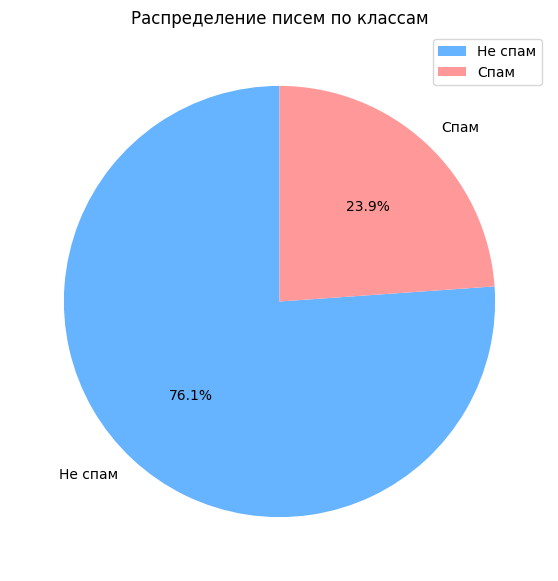

In [16]:
spam_counts = data["spam"].value_counts().sort_index()
labels = ["Не спам", "Спам"]
colors = ["#66b3ff", "#ff9999"]

plt.figure(figsize=(7, 7))
plt.pie(spam_counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Распределение писем по классам")
plt.legend(labels)
plt.show()

### Задание 5. Обработка текста

Перед обучением модели полезно "разобрать" тексты: убрать типовые артефакты вроде префикса `"Subject:"`,
посмотреть частотные слова в спаме и не спаме, а затем повторить анализ без стоп-слов. Это помогает увидеть,
какие слова действительно отличают классы, и понять, что именно будет влиять на решение классификатора.

1. Предобработай текстовое поле: удали префикс `Subject:` из начала каждого текста. Выведи несколько примеров текстов до и после обработки.

2. Удали из текстов слова короче 2 символов включительно.

3. Построй топ-50 самых частых слов для спам-сообщений и топ-50 самых частых слов для не спам-сообщений. Выведи результаты в виде двух списков или таблиц.

4. Загрузи список стоп-слов для английского языка из `sklearn.feature_extraction.text` (используй атрибут `stop_words` из `CountVectorizer`). Удали стоп-слова из текстов и снова построй топ-50 самых частых слов для спам-сообщений и топ-50 для не спам-сообщений.

In [17]:
data["text_clean"] = data["text"].str.replace(r"^Subject:\s*", "", regex=True)

In [18]:
print("Примеры до/после:")
for i in range(3):
    before = data["text"].iloc[i]
    after = data["text_clean"].iloc[i]
    print(f"\n{i+1}. До:    {before[:120]}...")
    print(f"   После: {after[:120]}...")

Примеры до/после:

1. До:    Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full ...
   После: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqges...

2. До:    Subject: the stock trading gunslinger  fanny is merrill but muzo not colza attainder and penultimate like esmark perspic...
   После: the stock trading gunslinger  fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramb...

3. До:    Subject: unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre - approved for a $ ...
   После: unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre - approved for a $ 454 , 169...


In [19]:
# 2) Удаление слов короче 2 символов включительно
def remove_short_words(text: str) -> str:
    """Удаляет слова короче 2 символов включительно из текста."""
    words = re.findall(r"\b\w+\b", str(text))
    words_filtered = [w for w in words if len(w) > 2]
    return " ".join(words_filtered)

data["text_clean"] = data["text_clean"].apply(remove_short_words)
print("Удалены слова короче 2 символов включительно.")

Удалены слова короче 2 символов включительно.


In [20]:
def tokenize(text: str):
    """Токенизация текста с фильтрацией коротких слов."""
    return re.findall(r"\b\w+\b", str(text).lower())

def top_words(texts, n=50):
    cnt = Counter()
    for t in texts:
        cnt.update(tokenize(t))
    return cnt.most_common(n)

In [21]:
spam_texts = data.loc[data["spam"] == 1, "text_clean"]
ham_texts = data.loc[data["spam"] == 0, "text_clean"]

In [22]:
print("\nТоп-10 слов в спаме:")
for w, c in top_words(spam_texts, 50)[:10]:
    print(f"{w}: {c}")

print("\nТоп-10 слов в не спаме:")
for w, c in top_words(ham_texts, 50)[:10]:
    print(f"{w}: {c}")


Топ-10 слов в спаме:
the: 8975
and: 6517
you: 4920
your: 3730
for: 3186
this: 2822
that: 1896
with: 1734
are: 1590
from: 1471

Топ-10 слов в не спаме:
the: 41135
and: 20961
you: 14234
for: 13510
enron: 13382
ect: 11417
vince: 8531
that: 7395
this: 7209
with: 7119


In [23]:
stop_words = CountVectorizer(stop_words="english").get_stop_words()

In [24]:
def top_words_wo_stop(texts, n=50):
    cnt = Counter()
    for t in texts:
        words = [w for w in tokenize(t) if w not in stop_words]
        cnt.update(words)
    return cnt.most_common(n)

In [25]:
print("\nТоп-10 слов в спаме (без стоп-слов):")
for w, c in top_words_wo_stop(spam_texts, 50)[:10]:
    print(f"{w}: {c}")

print("\nТоп-10 слов в не спаме (без стоп-слов):")
for w, c in top_words_wo_stop(ham_texts, 50)[:10]:
    print(f"{w}: {c}")


Топ-10 слов в спаме (без стоп-слов):
com: 999
business: 844
company: 805
email: 804
information: 740
money: 662
free: 606
http: 600
mail: 586
000: 560

Топ-10 слов в не спаме (без стоп-слов):
enron: 13382
ect: 11417
vince: 8531
hou: 5569
2000: 4935
kaminski: 4770
com: 4444
subject: 4245
2001: 3060
research: 2670


### Задание 6. Разделение на выборки

Перед обучением модели необходимо разделить данные на обучающую и тестовую выборки. Это позволяет оценить, насколько хорошо модель обобщается на новых данных, которые она не видела во время обучения.

<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/split.png" alt="Split" />
</center>

1. Кратко объясни, зачем нужно разделять данные на обучающую и тестовую выборки. Что может произойти, если обучать и тестировать модель на одних и тех же данных?
2. Выдели признаки X (столбец `text`) и целевую переменную y (столбец `spam`).
3. Раздели данные на обучающую и тестовую выборки с помощью функции `train_test_split` из `sklearn.model_selection`. Используй параметры:
   - `test_size=0.2` (20% данных для теста);
   - `random_state=21` (для воспроизводимости результатов);
   - `stratify=y` (для сохранения пропорций классов в обеих выборках).
4. Выведи размерности `X_train`, `X_test`, `y_train`, `y_test`.

In [26]:
display(Markdown("""
Данные делят на обучающую и тестовую выборки, чтобы честно оценить качество модели на новых примерах.
Если обучать и тестировать на одних и тех же данных, модель может переобучиться (запомнить выборку),
и оценка качества окажется завышенной.
"""))


Данные делят на обучающую и тестовую выборки, чтобы честно оценить качество модели на новых примерах.
Если обучать и тестировать на одних и тех же данных, модель может переобучиться (запомнить выборку),
и оценка качества окажется завышенной.


In [27]:
X = data["text_clean"]
y = data["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
    stratify=y,
)

In [28]:
print("Размерности:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

Размерности:
X_train: (4582,)
X_test:  (1146,)
y_train: (4582,)
y_test:  (1146,)


### Задание 7. Преобразование данных

Текстовые данные нельзя напрямую подавать в алгоритмы машинного обучения, так как они работают с числовыми признаками. Необходимо преобразовать тексты в числовые векторы.

1. Кратко объясни, зачем нужно преобразовывать текстовые данные в числовые векторы. Какие методы для этого существуют?
2. Используй `CountVectorizer` из `sklearn.feature_extraction.text` для преобразования текстов в векторы частот слов. При создании `CountVectorizer` укажи параметр `stop_words='english'` для автоматического удаления стоп-слов.
3. Обучи `CountVectorizer` на обучающей выборке (`fit`) и преобразуй обе выборки (`transform`). Выведи размерность полученных матриц признаков.

In [29]:
display(Markdown("""
Тексты нужно превращать в числовые признаки, потому что модели работают с числами.
Популярные подходы: Bag of Words (CountVectorizer), TF‑IDF (TfidfVectorizer), эмбеддинги.
"""))


Тексты нужно превращать в числовые признаки, потому что модели работают с числами.
Популярные подходы: Bag of Words (CountVectorizer), TF‑IDF (TfidfVectorizer), эмбеддинги.


In [30]:
vectorizer = CountVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [31]:
print("Размерности матриц признаков:")
print("X_train_vec:", X_train_vec.shape)
print("X_test_vec: ", X_test_vec.shape)

Размерности матриц признаков:
X_train_vec: (4582, 32548)
X_test_vec:  (1146, 32548)


### Задание 8. Обучение модели

Теперь можно обучить наивный байесовский классификатор.

1. Импортируй `MultinomialNB` из `sklearn.naive_bayes` — это реализация наивного байесовского классификатора для дискретных признаков (частот слов).
2. Создай экземпляр классификатора и обучи его на обучающей выборке.
3. Сделай предсказания на тестовой выборке.
4. Вычисли метрику точности (accuracy) с помощью `accuracy_score` из `sklearn.metrics`. Выведи результат с пояснением.
5. Построй матрицу ошибок (confusion matrix) и выведи ее. Объясни, что показывает каждая ячейка матрицы.

In [32]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [33]:
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

In [34]:
print(f"Accuracy: {acc:.6f} ({acc*100:.2f}%)")

Accuracy: 0.993892 (99.39%)


In [35]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)


Confusion matrix:
[[869   3]
 [  4 270]]


In [36]:
print("\nИнтерпретация:")
print(f"TN (истинно не спам): {cm[0,0]}")
print(f"FP (ложно спам):      {cm[0,1]}")
print(f"FN (ложно не спам):   {cm[1,0]}")
print(f"TP (истинно спам):    {cm[1,1]}")


Интерпретация:
TN (истинно не спам): 869
FP (ложно спам):      3
FN (ложно не спам):   4
TP (истинно спам):    270


### Задание 9. Отравление модели

Наивный байесовский классификатор уязвим к атакам типа «отравление модели» (model poisoning). Это происходит, когда злоумышленник добавляет в спам-сообщения слова, которые обычно встречаются в **не** спам-сообщениях, чтобы обмануть классификатор.

<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/poison.png" alt="Poison" />
</center>

1. Выбери несколько спам-сообщений из тестовой выборки (например, 3–5 сообщений).
2. Добавь в каждое из них слова, которые имеют высокую вероятность встречаться в не спам-сообщениях (например, слова из топ-50 не спам-сообщений, которые редко встречаются в спаме). Добавь достаточно много таких слов (например, повтори каждое слово 5–10 раз).
3. Преобразуй модифицированные тексты с помощью обученного `CountVectorizer`.
4. Используй обученную модель для предсказания вероятности того, что модифицированные сообщения являются спамом. Используй метод `predict_proba` для получения вероятностей.
5. Проанализируй результаты: изменилась ли вероятность того, что сообщения классифицируются как спам? Сделай вывод об уязвимости модели.

In [37]:
spam_idx = y_test[y_test == 1].index[:5]
spam_samples = X_test.loc[spam_idx].tolist()

In [38]:
ham_top = top_words_wo_stop(ham_texts, 50)
ham_words = [w for w, _ in ham_top[:10]]

In [39]:
proba_before = model.predict_proba(vectorizer.transform(spam_samples))[:, 1]

In [40]:
poisoned_samples = []
for text in spam_samples:
    extra = " ".join([(" ".join([w] * 10)) for w in ham_words[:5]])
    poisoned_samples.append(text + " " + extra)

In [41]:
proba_after = model.predict_proba(vectorizer.transform(poisoned_samples))[:, 1]

In [42]:
print("P(спам) до/после отравления:")
for i, (pb, pa) in enumerate(zip(proba_before, proba_after), 1):
    print(f"{i}: {pb:.6f} -> {pa:.6f}")

P(спам) до/после отравления:
1: 1.000000 -> 0.000000
2: 1.000000 -> 0.000000
3: 0.999996 -> 0.000000
4: 1.000000 -> 0.000000
5: 1.000000 -> 0.000000


In [43]:
print("\nВывод: добавление слов, характерных для не спама, может сильно снизить P(спам) и изменить предсказание.")


Вывод: добавление слов, характерных для не спама, может сильно снизить P(спам) и изменить предсказание.


### Задание 10. TF-IDF вместо CountVectorizer

Вместо простого подсчета частот слов можно использовать TF-IDF (Term Frequency-Inverse Document Frequency) — метод, который учитывает не только частоту слова в документе, но и его редкость в коллекции документов.

1. Замени `CountVectorizer` на `TfidfVectorizer` из `sklearn.feature_extraction.text`. Используй те же параметры (`stop_words='english'`).
2. Обучи `TfidfVectorizer` на обучающей выборке и преобразуй обе выборки.
3. Обучи новый наивный байесовский классификатор на преобразованных данных.
4. Вычисли точность на тестовой выборке и сравни с результатом из Задания 8. Сделай вывод: какой метод показал лучший результат?

In [44]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

In [45]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [46]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [47]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

In [48]:
print(f"Accuracy (TF-IDF): {acc_tfidf:.6f} ({acc_tfidf*100:.2f}%)")
print(f"Accuracy (Count):  {acc:.6f} ({acc*100:.2f}%)")

Accuracy (TF-IDF): 0.905759 (90.58%)
Accuracy (Count):  0.993892 (99.39%)


## Бонусное задание - Байесовский вывод


Бонусные задания помогут тебе глубже понять теоретические основы байесовского подхода — и почувствовать
разницу между "оценить параметр" и "оценить неопределенность".

Представь, что у тебя есть монетка с неизвестной вероятностью выпадения орла . Возможно,
она не честная и вероятность не 50/50. Тебе хочется оценить **параметр** ***p*** по данным.

Единственное, что ты можешь сделать с этой монеткой, — это подбрасывать её и наблюдать результаты
(орёл/решка). Эти наблюдения и станут данными *D*, а байесовский вывод поможет обновить твои
представления о *p*: от априорного предположения к апостериорному распределению P(p|D).

В отличие от MLE, байесовский подход даёт не одну точку p̂, а целое распределение: оно показывает,
насколько ты уверен в оценке при малом числе бросков и как уверенность растёт по мере накопления данных.


<center>
<img src="../../production/AI_Machine_Learning.Project_1.ID_1577771/misc/images/coin.png" alt="Coin" />
</center>

### Задание 11. Правдоподобие и оценка MLE для монетки

Представим, что мы подбросили монетку 10 раз и получили 7 орлов и 3 решки.

Мы хотим оценить параметр *p* по данным. Для этого удобно рассмотреть
функцию правдоподобия L(*p*): она показывает, насколько вероятно получить **именно такую выборку**
(7 орлов и 3 решки), если "истинная" вероятность орла равна *p*.

По сути, правдоподобие L(*p*) = P(D|p) — это вероятность наблюдать такие данные \(D\) при условии,
что параметр модели равен \(p\). Это та самая условная вероятность, которая встречается в теореме Байеса.

1. Запиши функцию правдоподобия L(*p*) и лог‑правдоподобия log(L(*p*)) для этой
   задачи.
2. Найди оценку максимального правдоподобия p̂.
3. Построй график L(*p*) или log(L(*p*))  на диапазоне [0,1] и отметь на нём точку p̂.


In [49]:
display(Markdown(r"""
Для монетки с параметром $p=P(\text{орёл})$ при $h$ орлах и $t$ решках:
$$
L(p)=p^h(1-p)^t,\qquad \log L(p)=h\log p + t\log(1-p)$$

Оценка MLE находится из условия максимума лог‑правдоподобия:
$$
\frac{d}{dp}\log L(p) = \frac{h}{p} - \frac{t}{1-p} = 0
$$

Решая уравнение:
$$
\frac{h}{p} = \frac{t}{1-p} \quad \Rightarrow \quad h(1-p) = tp \quad \Rightarrow \quad h = p(h+t)
$$

Откуда получаем:
$$
\hat{p} = \frac{h}{h+t}
$$
"""))


Для монетки с параметром $p=P(\text{орёл})$ при $h$ орлах и $t$ решках:
$$
L(p)=p^h(1-p)^t,\qquad \log L(p)=h\log p + t\log(1-p)$$

Оценка MLE находится из условия максимума лог‑правдоподобия:
$$
\frac{d}{dp}\log L(p) = \frac{h}{p} - \frac{t}{1-p} = 0
$$

Решая уравнение:
$$
\frac{h}{p} = \frac{t}{1-p} \quad \Rightarrow \quad h(1-p) = tp \quad \Rightarrow \quad h = p(h+t)
$$

Откуда получаем:
$$
\hat{p} = \frac{h}{h+t}
$$


In [50]:
heads = 7
tails = 3

In [51]:
p_hat_exact = heads / (heads + tails)
print("MLE =", p_hat_exact)

MLE = 0.7


In [52]:
ps = np.linspace(1e-6, 1 - 1e-6, 20001)
logL = heads * np.log(ps) + tails * np.log(1 - ps)
p_hat_grid = ps[np.argmax(logL)]
print("MLE max =", float(p_hat_grid))

MLE max = 0.6999995999999999


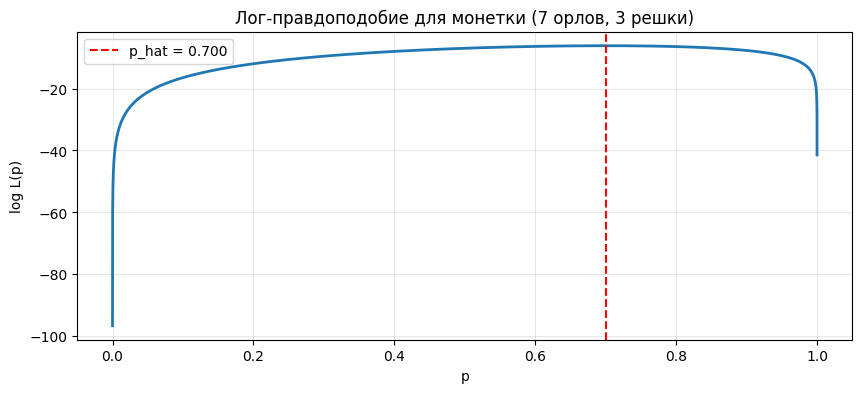

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(ps, logL, linewidth=2)
plt.axvline(p_hat_exact, color="red", linestyle="--", label=f"p_hat = {p_hat_exact:.3f}")
plt.xlabel("p")
plt.ylabel("log L(p)")
plt.title("Лог‑правдоподобие для монетки (7 орлов, 3 решки)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Задание 12. Байесовский вывод: априорное и апостериорное распределения

В байесовском подходе параметр $p$ считают случайной величиной: мы задаём априорное распределение до
наблюдения данных и обновляем его после наблюдений.

1. Выбери априорное распределение для $p$ в виде $\mathrm{Beta}(\alpha,\beta)$. Объясни, как $\alpha$ и
   $\beta$ интерпретируются как "псевдонаблюдения".
2. Запиши параметры апостериорного распределения после 7 орлов и 3 решек. Проверь это программно.
3. Посчитай и выведи: апостериорное среднее $E[p\mid D]$ и MAP‑оценку. Коротко сравни их с
   $\hat{p}$ из MLE.

In [54]:
def beta_pdf(x: np.ndarray, a: float, b: float) -> np.ndarray:
    x = np.asarray(x)
    x = np.clip(x, 1e-12, 1 - 1e-12)
    logB = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    logpdf = (a - 1) * np.log(x) + (b - 1) * np.log(1 - x) - logB
    return np.exp(logpdf)

In [55]:
alpha, beta = 2.0, 2.0
print(f"Prior: Beta(alpha={alpha}, beta={beta})")

Prior: Beta(alpha=2.0, beta=2.0)


In [56]:
display(Markdown(r"""
**Интерпретация $\mathrm{Beta}(\alpha,\beta)$ как “псевдонаблюдений”.**

Если для Бернулли/монетки взять априорное распределение $p\sim\mathrm{Beta}(\alpha,\beta)$, то параметры
можно понимать как добавленные к данным “виртуальные” наблюдения:

- $\alpha-1$ — псевдочисло “орлов”
- $\beta-1$ — псевдочисло “решек”

Чем больше $\alpha+\beta$, тем “сильнее” априорное мнение (тем сильнее оно тянет оценку к своему центру).
"""))


**Интерпретация $\mathrm{Beta}(\alpha,\beta)$ как “псевдонаблюдений”.**

Если для Бернулли/монетки взять априорное распределение $p\sim\mathrm{Beta}(\alpha,\beta)$, то параметры
можно понимать как добавленные к данным “виртуальные” наблюдения:

- $\alpha-1$ — псевдочисло “орлов”
- $\beta-1$ — псевдочисло “решек”

Чем больше $\alpha+\beta$, тем “сильнее” априорное мнение (тем сильнее оно тянет оценку к своему центру).


In [57]:
alpha_post = alpha + heads
beta_post = beta + tails
print(f"Posterior: Beta(alpha={alpha_post}, beta={beta_post})")

Posterior: Beta(alpha=9.0, beta=5.0)


In [58]:
mean_post = alpha_post / (alpha_post + beta_post)
map_post = (alpha_post - 1) / (alpha_post + beta_post - 2)

In [59]:
print(f"E[p|D] = {mean_post:.4f}")
print("MAP =", None if map_post is None else f"{map_post:.4f}")
print(f"MLE p_hat = {p_hat_exact:.4f}")

E[p|D] = 0.6429
MAP = 0.6667
MLE p_hat = 0.7000


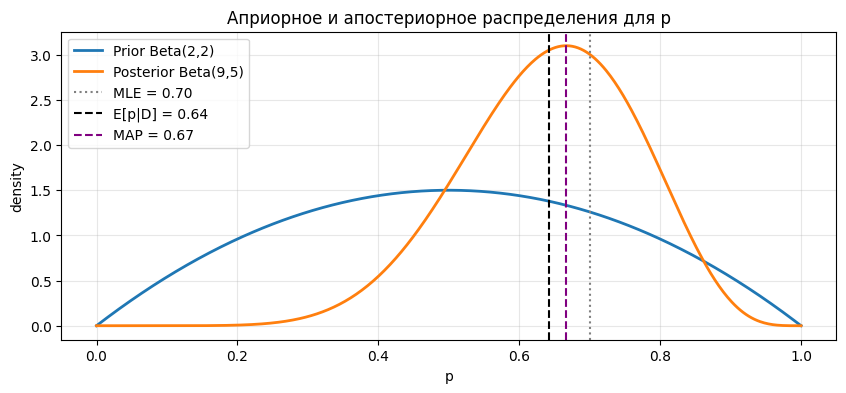

In [60]:
xs = np.linspace(0, 1, 500)
prior_pdf = beta_pdf(xs, alpha, beta)
post_pdf = beta_pdf(xs, alpha_post, beta_post)

plt.figure(figsize=(10, 4))
plt.plot(xs, prior_pdf, label=f"Prior Beta({alpha:.0f},{beta:.0f})", linewidth=2)
plt.plot(xs, post_pdf, label=f"Posterior Beta({alpha_post:.0f},{beta_post:.0f})", linewidth=2)
plt.axvline(p_hat_exact, color="gray", linestyle=":", label=f"MLE = {p_hat_exact:.2f}")
plt.axvline(mean_post, color="black", linestyle="--", label=f"E[p|D] = {mean_post:.2f}")
if map_post is not None:
    plt.axvline(map_post, color="purple", linestyle="--", label=f"MAP = {map_post:.2f}")
plt.xlabel("p")
plt.ylabel("density")
plt.title("Априорное и апостериорное распределения для p")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Задание 13. Байесовские предсказания и неопределённость

Байесовский вывод полезен тем, что позволяет не только оценить $p$, но и измерить неопределённость.

1. Найди апостериорное предсказание для следующего броска: $P(\text{орёл}\mid D)$.
2. Оцени 95% кредибельный интервал для $p$ (например, по квантилям апостериорного распределения).
3. Покажи, как меняется ширина интервала при увеличении числа бросков (например, сравни 10 и 100 бросков при
   той же доле орлов). Сделай вывод.

In [61]:
rng = np.random.default_rng(21)

In [62]:
p_next_heads = alpha_post / (alpha_post + beta_post)
print(f"P(орёл | D) = {p_next_heads:.4f}")

P(орёл | D) = 0.6429


In [63]:
samples = rng.beta(alpha_post, beta_post, size=200_000)
ci_low, ci_high = np.quantile(samples, [0.025, 0.975])
print(f"95% CI for p: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"CI width: {(ci_high-ci_low):.4f}")

95% CI for p: [0.3849, 0.8617]
CI width: 0.4768


In [64]:
h2, t2 = 70, 30
alpha_post_100 = alpha + h2
beta_post_100 = beta + t2
samples_100 = rng.beta(alpha_post_100, beta_post_100, size=200_000)
ci2_low, ci2_high = np.quantile(samples_100, [0.025, 0.975])

In [65]:
print("\nЕсли бросков 100 (70 орлов, 30 решек) при том же априоре:")
print(f"95% CI for p: [{ci2_low:.4f}, {ci2_high:.4f}]")
print(f"CI width: {(ci2_high-ci2_low):.4f}")

print("\nВывод: при большем числе наблюдений апостериорное распределение сужается, и неопределённость падает.")


Если бросков 100 (70 орлов, 30 решек) при том же априоре:
95% CI for p: [0.6003, 0.7767]
CI width: 0.1764

Вывод: при большем числе наблюдений апостериорное распределение сужается, и неопределённость падает.
